## Example 2e:
Example workflow that trains a flow-matching model to predict the distribution of amplitude and
phase aberration coefficients from a single image (not a z-stack).

Model trains itself using synthetic examples generated from the forwards model on-the-fly, with
the absolute focus position randomly jittered per example so the decoder learns to characterize
aberrations without relying on a precisely known nominal focus. Because a rigid focus shift is
physically the same pupil operator as the m=0 radial phase terms (defocus, spherical, ...), the
jitter offset is *folded into the phase labels*: the model predicts the effective aberration
actually present in the image, rather than being handed labels that contradict it.

Fitting the model amounts to fitting a change-of-variable transformation, conditioned on
the observed image(s), that takes the aberration coefficients from a standard normal
prior to the predicted posterior. This transformation is represented as a velocity vector
field, which is integrated at inference time to sample the actual, predicted, coefficients.

See, e.g., Lipman et al., "Flow matching for generative modeling," arXiv:2210.02747v2 (2023).

In [1]:
import logging
import math
import warnings

import numpy as np
import torch
import pytorch_lightning as pl
from lightning_fabric.utilities.warnings import PossibleUserWarning
from matplotlib import pyplot

In [2]:
# Silence a few nuisance warnings:
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX`")
warnings.filterwarnings("ignore", message=r".*isinstance\(treespec, LeafSpec\).*")

In [3]:
from cynosure.config_defaults import (
    get_default_training_config,
    get_default_simulation_config,
    get_default_optical_config,
    get_default_phase_config,
    get_default_amplitude_config,
    get_default_phase_prior,
    get_default_amplitude_prior,
    get_default_noise_config,
    get_default_velocity_config,
)
from cynosure.object_distribution import FixedBead
from cynosure.utilities.training_utils import NoValidationBar
from cynosure.zstack_decoding import ZstackSolver_FlowMatching

#### Simulation setup

In [4]:
train_cfg = get_default_training_config()
sim_cfg = get_default_simulation_config()
opt_cfg = get_default_optical_config()
phase_cfg = get_default_phase_config()
amp_cfg = get_default_amplitude_config()
phase_prior = get_default_phase_prior()
amp_prior = get_default_amplitude_prior()
noise_cfg = get_default_noise_config()
vel_cfg = get_default_velocity_config()

object_distrib = FixedBead(sim_cfg, bead_diameter=0.1)

In [5]:
rng_seed = 123
z_jitter = 1.0  # um
device = "cuda" if torch.cuda.is_available() else "cpu"

#### Solver setup and training

In [6]:
pl.seed_everything(rng_seed, workers=True)
solver = ZstackSolver_FlowMatching(
    train_cfg=train_cfg,
    sim_cfg=sim_cfg,
    optics_cfg=opt_cfg,
    phase_cfg=phase_cfg,
    amp_cfg=amp_cfg,
    phase_prior_cfg=phase_prior,
    amp_prior_cfg=amp_prior,
    vel_cfg=vel_cfg,
    object_distribution=object_distrib,
    z_objective=torch.zeros(1),
    z_jitter=z_jitter,
    noise_cfg=noise_cfg,
    hidden_channels=(8, 8),
    embedding_dims=32,
)
solver = solver.to(device)

Seed set to 123


In [7]:
trainer = pl.Trainer(
    max_epochs=80,
    accelerator=device,
    log_every_n_steps=50,
    callbacks=[NoValidationBar()],
)
trainer.fit(solver)
solver = solver.eval()

Sanity Checking: |                                                                                     | 0/? […

Training: |                                                                                            | 0/? […

#### Sanity checking the results

Sample 8 new sets of aberrations, and forwards-simulate an image for each.
For each image, sample 256 images from the predicted posterior.

In [8]:
batch_size = 8
num_samples = 256
with torch.inference_mode():
    images, phase_coefs, amp_coefs = solver.simulator.create_examples(batch_size)
    pred_phase_coefs, pred_amp_coefs = solver.predict_samples(images, num_samples)
    pred_images = solver.simulator.simulate_normalized_stacks(
        pred_phase_coefs.reshape(batch_size*num_samples, -1),
        pred_amp_coefs.reshape(batch_size*num_samples, -1),
    ).unflatten(0, (batch_size, num_samples))  # [batch_size, num_samples, num_z, H, W]

In [9]:
kept_labels = solver.coefficients.nonpinned_labels
joined = solver.coefficients.join(phase_coefs, amp_coefs)
joined_pred = solver.coefficients.join(pred_phase_coefs, pred_amp_coefs)

# the flow only predicts the non-pinned coefficients, so drop the pinned ones to line up with `kept_labels`
coefs = solver.coefficients.gather_nonpinned(joined)  # [batch_size, num_kept]
pred_coefs = solver.coefficients.gather_nonpinned(joined_pred)  # [batch_size, num_samples, num_kept]

Pick the `batch_index=0` element arbitrarily. For each coefficient, plot the distribution of sampled predictions alongside the true value (vertical line).

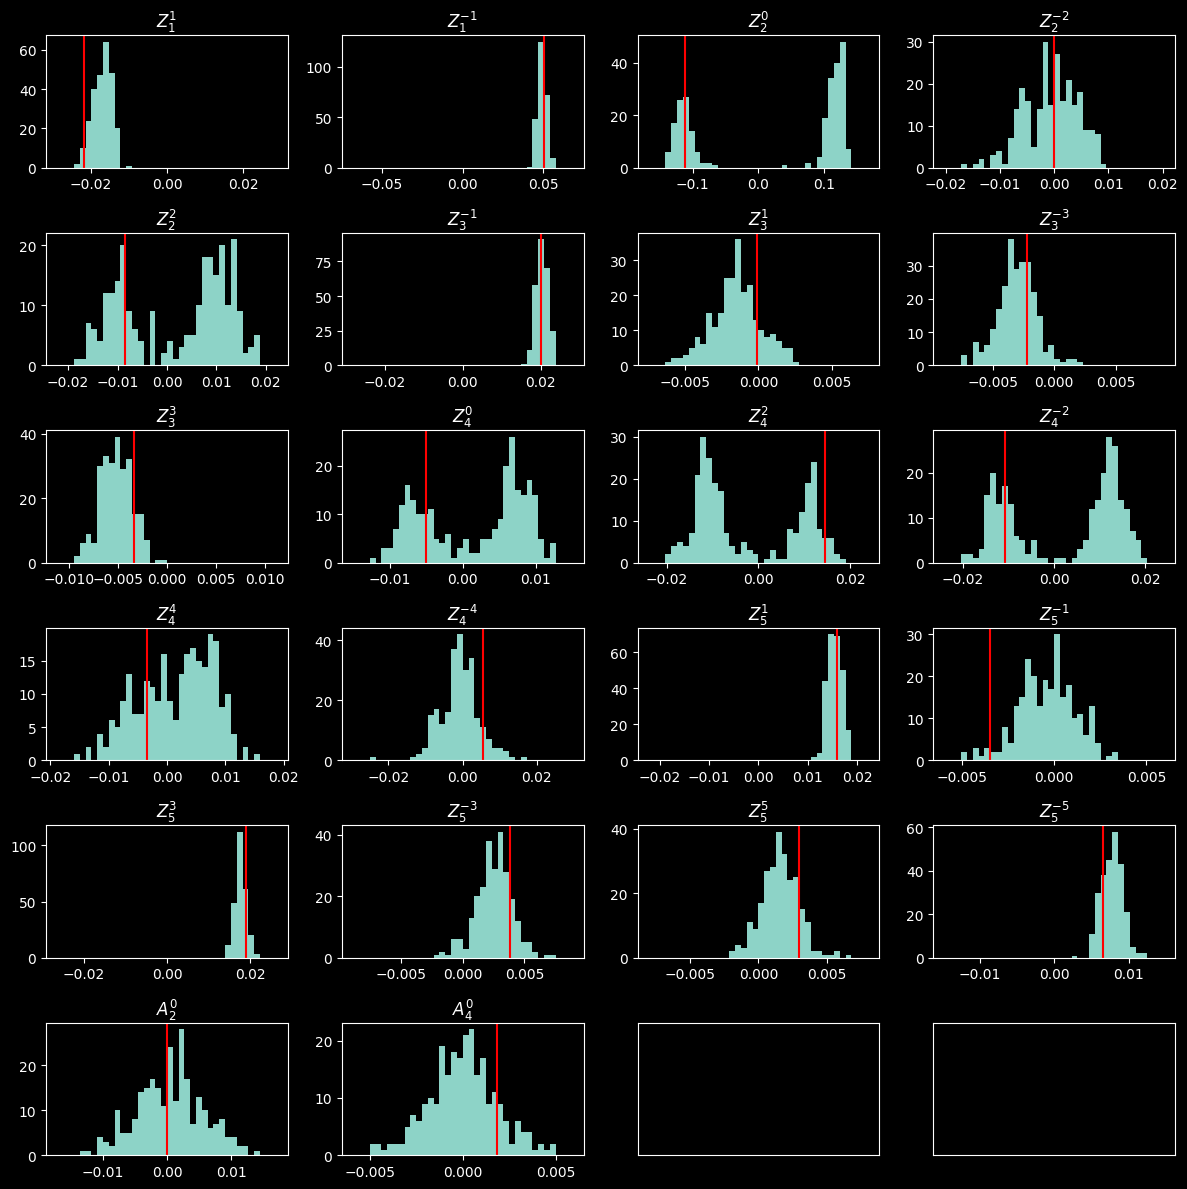

In [10]:
num_plots = solver.coefficients.num_nonpinned_coefs
panel_size = 2
aspect_ratio = 1.5
num_cols = 4
num_rows = int(math.ceil(num_plots / num_cols))

bidx = 0

figsize = (num_cols * panel_size * aspect_ratio, num_rows * panel_size)
fig, axarr = pyplot.subplots(num_rows, num_cols, figsize=figsize)
for i, ax in enumerate(axarr.ravel()):
    if i < num_plots:
        lbl = kept_labels[i]
        target = coefs[bidx, i].numpy(force=True)
        pred_distrib = pred_coefs[bidx, :, i].numpy(force=True)
        bound = np.max(np.abs(pred_distrib))
        _ = ax.hist(pred_distrib, range=(-bound, bound), bins=32)
        ax.axvline(target, color="r")
        ax.set_xlim(-bound*1.3, bound*1.3)
        ax.set_title(lbl)
    else:
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()


For each batch element, plot a handful of images from the predicted posterior. They should all look similar to the true image, although some slight variation is reasonable.

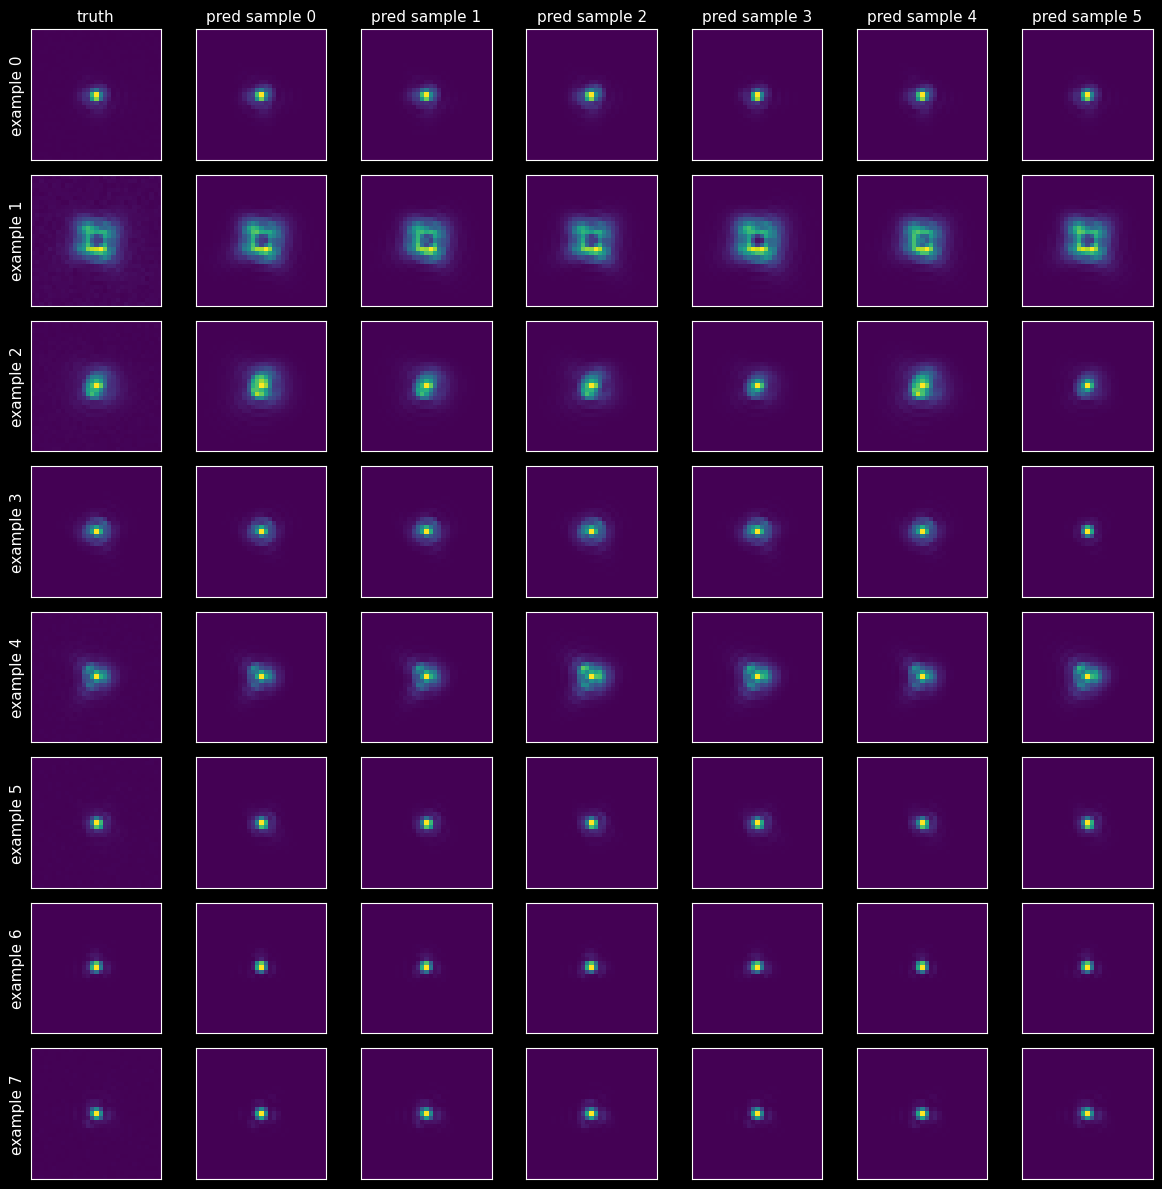

In [11]:
num_samples_to_show = 6
panel_size = 2
fig, axarr = pyplot.subplots(batch_size, 1+num_samples_to_show, figsize=(num_samples_to_show*panel_size, num_samples_to_show*panel_size))
for bidx in range(batch_size):
    axarr[bidx, 0].imshow(images[bidx, 0].numpy(force=True))
    for i in range(num_samples_to_show):
        axarr[bidx, i+1].imshow(pred_images[bidx, i, 0].numpy(force=True))

for ax in axarr.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
for bidx in range(batch_size):
    axarr[bidx, 0].set_ylabel(f"example {bidx}", size=11)
axarr[0, 0].set_title("truth", size=11)
for i in range(num_samples_to_show):
    axarr[0, i+1].set_title(f"pred sample {i}", size=11)
fig.tight_layout()